# Credit Risk Prediction - EDA

Exploratory Data Analysis for UCI Credit Card Default dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_excel('../data/raw/default of credit card clients.xls', header=1, engine='xlrd')
df.rename(columns={'default payment next month': 'default'}, inplace=True)
df.drop('ID', axis=1, inplace=True)

TARGET = 'default'
print(f"Shape: {df.shape}")
print(f"Default rate: {df[TARGET].mean():.2%}")


Shape: (30000, 24)
Default rate: 22.12%


In [2]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   30000 non-nu

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


## 1. Target Distribution

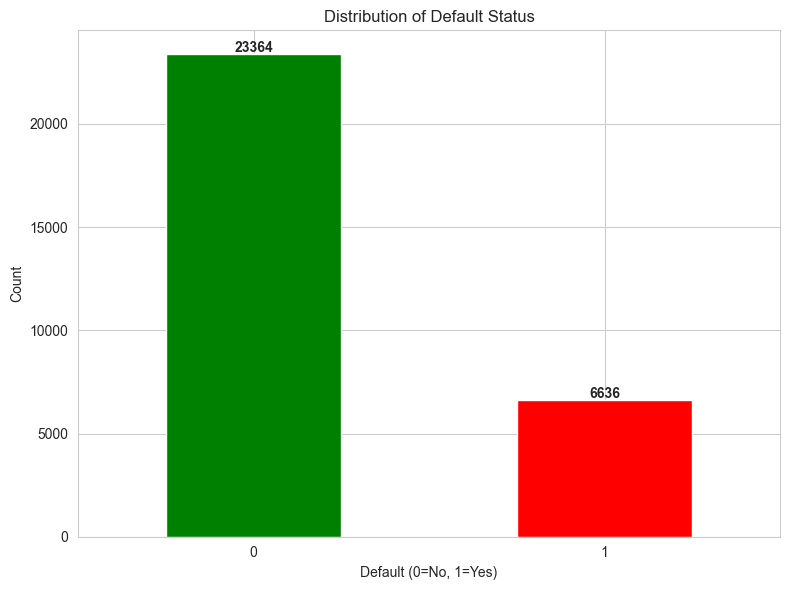

In [3]:
plt.figure(figsize=(8, 6))
df[TARGET].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution of Default Status')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
for i, v in enumerate(df[TARGET].value_counts()):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Correlation Heatmap

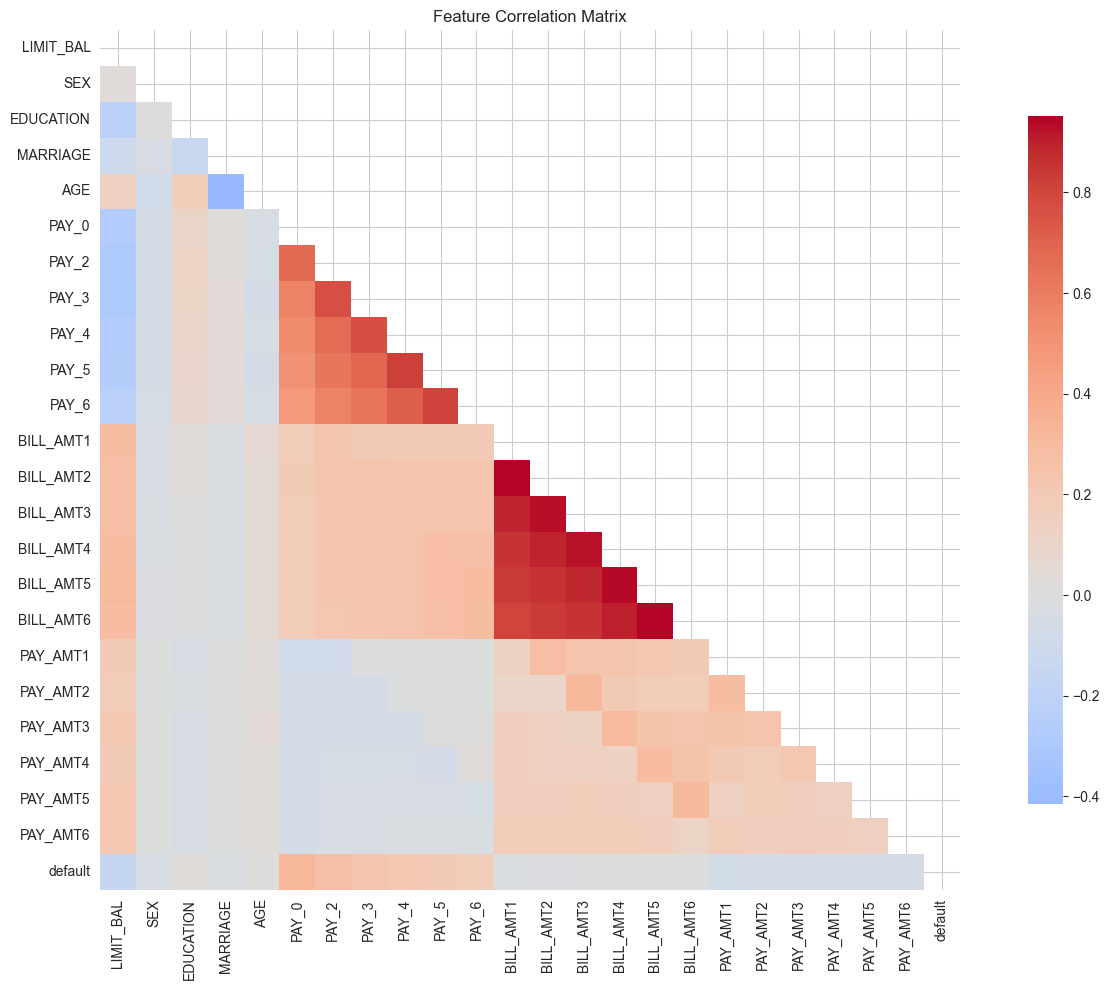


Top correlations with target:
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
EDUCATION    0.028006
AGE          0.013890
BILL_AMT6   -0.005372
BILL_AMT5   -0.006760
Name: default, dtype: float64


In [4]:
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop correlations with target:")
print(corr[TARGET].sort_values(ascending=False)[1:11])


## 3. Distribution of Key Features

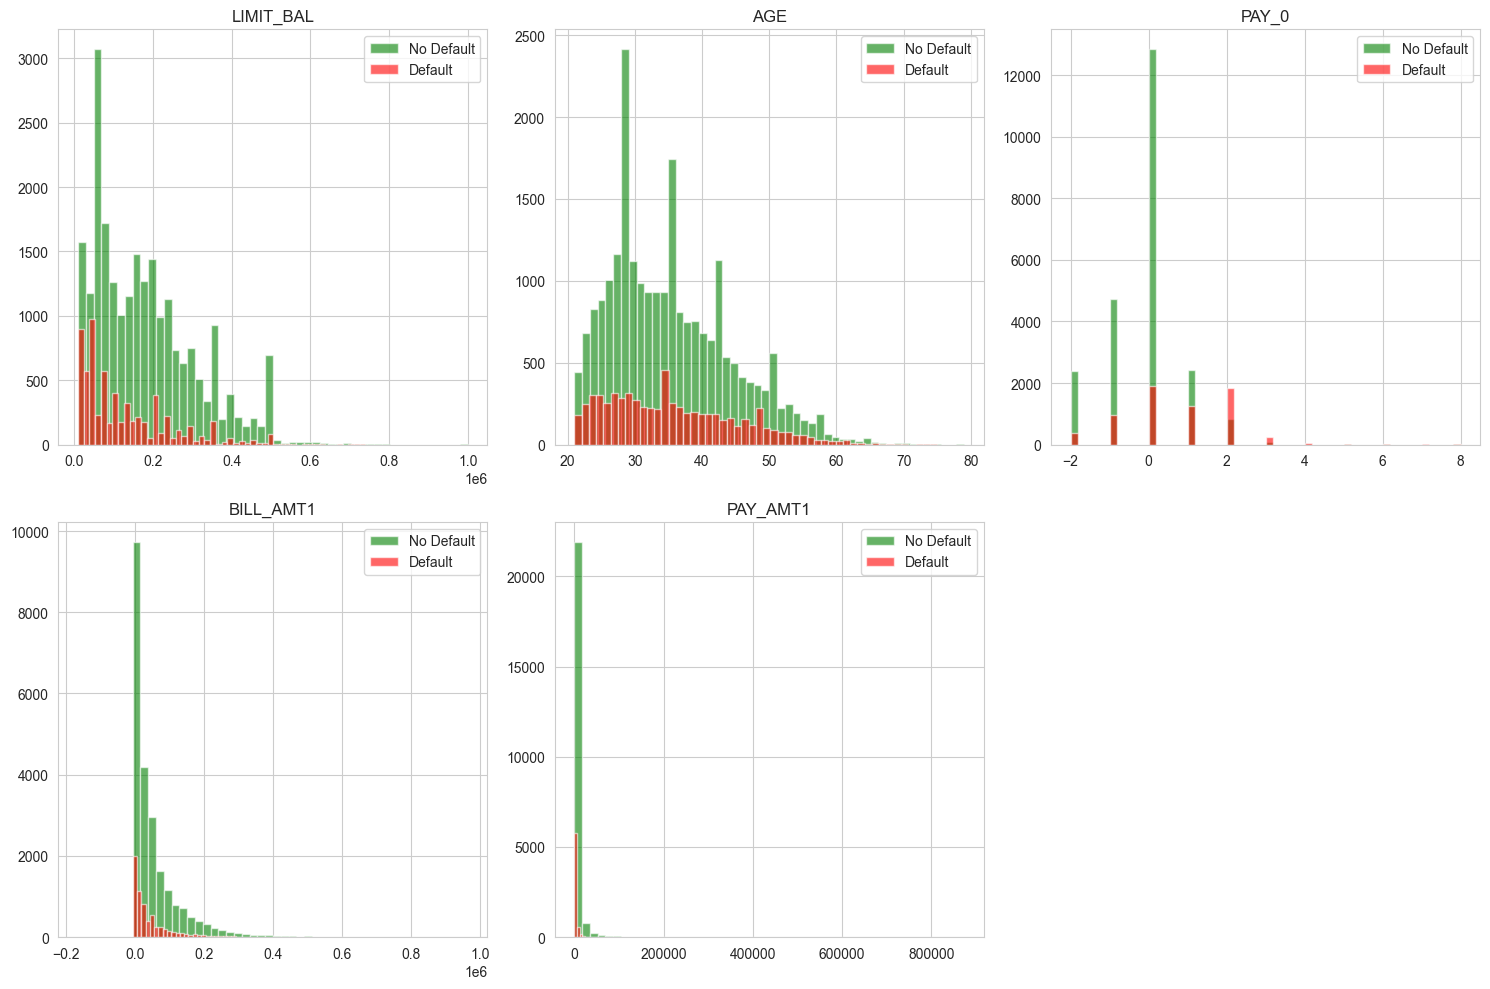

In [5]:
key_features = ['LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'PAY_AMT1']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    df[df[TARGET]==0][feat].hist(bins=50, alpha=0.6, label='No Default', ax=axes[i], color='green')
    df[df[TARGET]==1][feat].hist(bins=50, alpha=0.6, label='Default', ax=axes[i], color='red')
    axes[i].set_title(feat)
    axes[i].legend()

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/03_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Box Plots for Outlier Detection

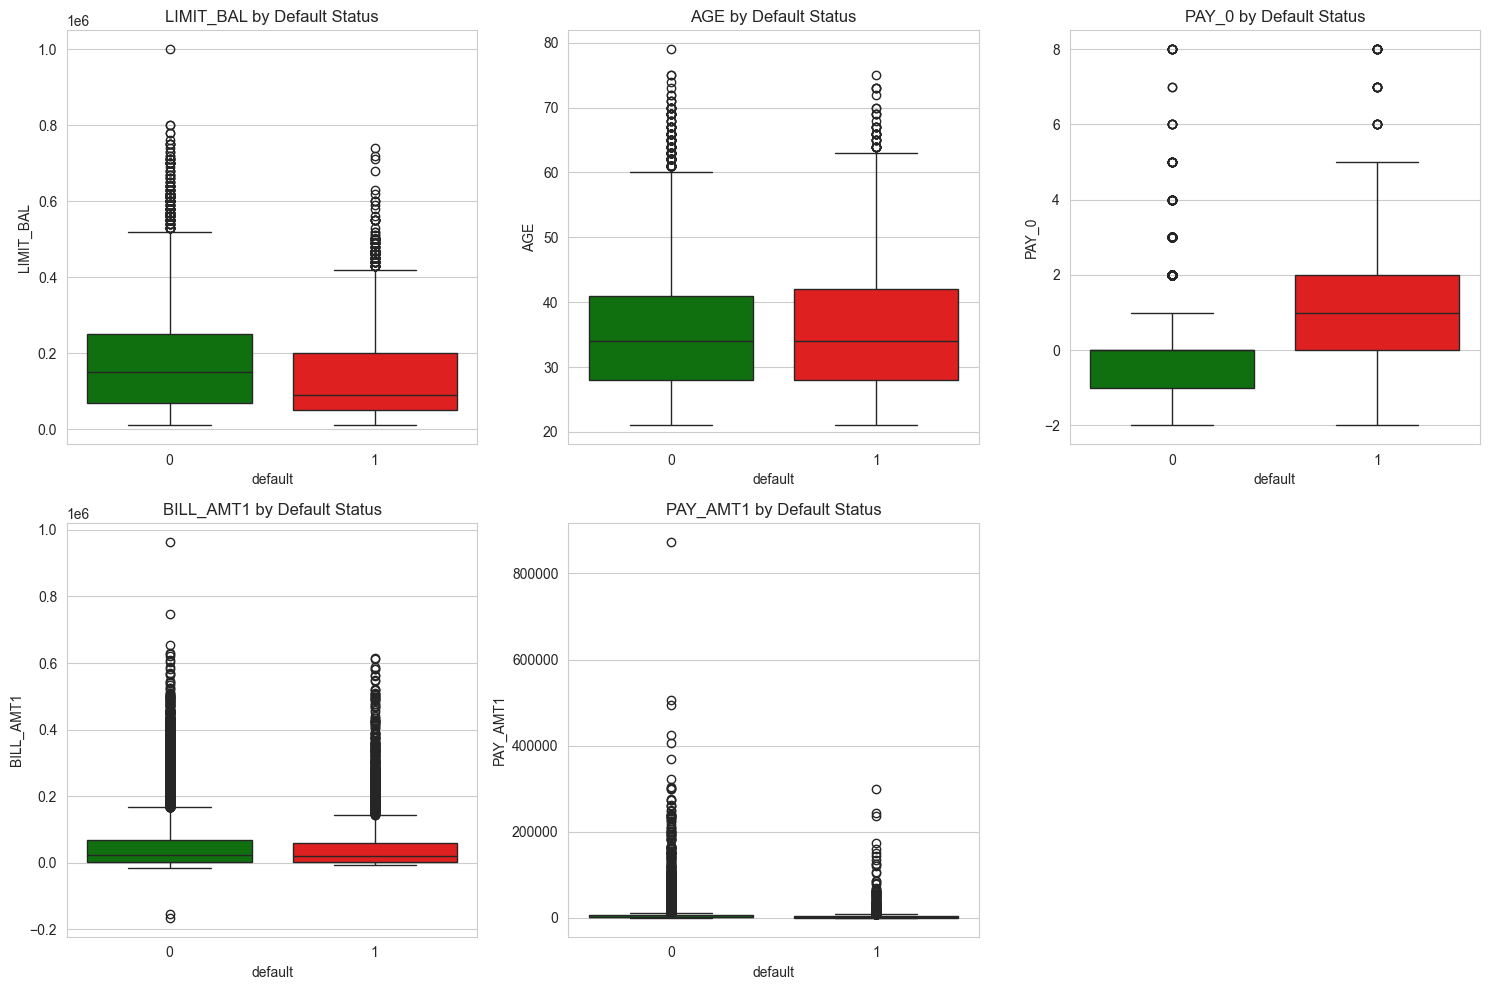

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.boxplot(data=df, x=TARGET, y=feat, ax=axes[i], palette=['green', 'red'])
    axes[i].set_title(f'{feat} by Default Status')

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/04_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Payment Status Analysis

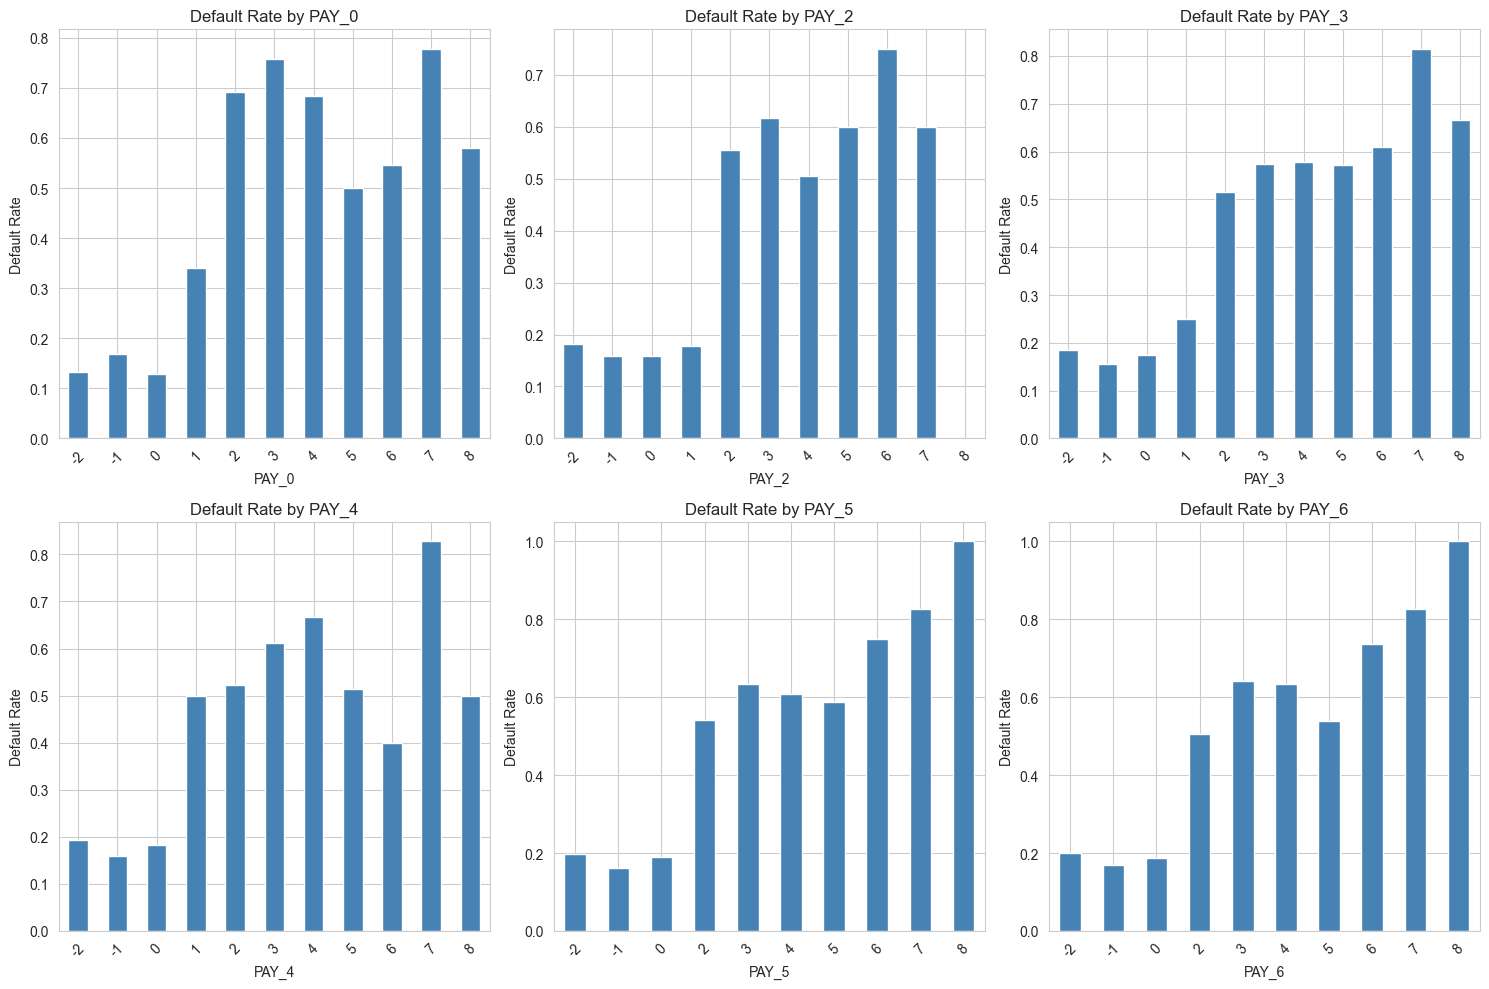

In [7]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(pay_cols):
    default_rates = df.groupby(col)[TARGET].mean()
    default_rates.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_ylabel('Default Rate')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/05_payment_status.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary Statistics

In [8]:
print("=== Summary Statistics by Default Status ===")
print(df.groupby(TARGET).agg({
    'LIMIT_BAL': ['mean', 'median', 'std'],
    'AGE': ['mean', 'median'],
    'PAY_0': ['mean', 'std'],
    'BILL_AMT1': ['mean', 'median'],
    'PAY_AMT1': ['mean', 'median']
}).round(2))


=== Summary Statistics by Default Status ===
         LIMIT_BAL                         AGE        PAY_0       BILL_AMT1  \
              mean    median        std   mean median  mean   std      mean   
default                                                                       
0        178099.73  150000.0  131628.36  35.42   34.0 -0.21  0.95  51994.23   
1        130109.66   90000.0  115378.54  35.73   34.0  0.67  1.38  48509.16   

                 PAY_AMT1          
          median     mean  median  
default                            
0        23119.5  6307.34  2459.5  
1        20185.0  3397.04  1636.0  
